<a href="https://colab.research.google.com/github/vencov/FAV_course/blob/main/TutCochModels/EX_DRNLmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DRNL (Dual-Resonance Non-Linear) Cochlear Model — Jepsen Implementation

Python port of the DRNL model implementaion according to study of Jepsen et al.


In [1]:
import numpy as np
from scipy.signal import lfilter
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 5)

def erb_space(low_freq, high_freq, n=100):
    """Array of n frequencies uniformly spaced on an ERB scale between low_freq
    and high_freq (Moore & Glasberg, 1983). Port of ERBSpace.m."""
    ear_q = 9.26449   # Glasberg & Moore parameters
    min_bw = 24.7
    idx = np.arange(n, 0, -1)
    cf_array = -(ear_q * min_bw) + np.exp(
        idx * (-np.log(high_freq + ear_q * min_bw) + np.log(low_freq + ear_q * min_bw)) / n
    ) * (high_freq + ear_q * min_bw)
    return cf_array

def get_drnl_param(cf):
    """DRNL filter parameters for normal hearing (Morten Jepsen, 2007).
    Port of getDRNLparam.m. Returns (lin, nlin) parameter dicts."""
    lin, nlin = {}, {}

    lin['CF_lin'] = 10 ** (-0.06762 + 1.01679 * np.log10(cf))
    lin['nGTfilt_lin'] = 2                                   # cascaded gammatone filters
    lin['LP_lin_cutoff'] = 10 ** (-0.06762 + 1.01 * np.log10(cf))
    lin['nLPfilt_lin'] = 4                                   # cascaded lowpass filters
    lin['g'] = 10 ** (4.20405 - 0.47909 * np.log10(cf))      # linear-path gain
    lin['BW_lin'] = 10 ** (0.03728 + 0.75 * np.log10(cf))

    nlin['CF_nlin'] = 10 ** (-0.05252 + 1.01650 * np.log10(cf))
    nlin['nGTfilt_nlin'] = 2
    nlin['BW_nlin'] = 10 ** (-0.03193 + 0.7 * np.log10(cf))
    nlin['LP_nlin_cutoff'] = 10 ** (-0.05252 + 1.01 * np.log10(cf))
    nlin['nLPfilt_nlin'] = 1

    # broken-stick nonlinearity coefficients; the 1500 Hz clamp for a,b below
    # CF matches the original comment: "the 1500 assumption is no good for
    # compression at low freq filters" but is what the MATLAB code does.
    if cf <= 1000:
        nlin['a'] = 10 ** (1.40298 + 0.81916 * np.log10(cf))
        nlin['b'] = 10 ** (1.61912 - 0.81867 * np.log10(cf))
    else:
        nlin['a'] = 10 ** (1.40298 + 0.81916 * np.log10(1500))
        nlin['b'] = 10 ** (1.61912 - 0.81867 * np.log10(1500))
    nlin['c'] = 10 ** (-0.60206)   # compression exponent

    return lin, nlin

def coef_gt_drnl(fc, bw, n, fs):
    """Gammatone filter coefficients for the DRNL implementation. Port of
    coefGtDRNL.m. n cascades are pre-convolved into a single (b, a) pair
    (the run-scripts always call this with n=1 and cascade by re-filtering
    instead, see drnl() below)."""
    theta = 2 * np.pi * fc / fs
    phi = 2 * np.pi * bw / fs
    alpha = -np.exp(-phi) * np.cos(theta)

    b1 = 2 * alpha
    b2 = np.exp(-2 * phi)
    a0 = np.abs(
        (1 + b1 * np.cos(theta) - 1j * b1 * np.sin(theta)
         + b2 * np.cos(2 * theta) - 1j * b2 * np.sin(2 * theta))
        / (1 + alpha * np.cos(theta) - 1j * alpha * np.sin(theta))
    )
    a1 = alpha * a0

    b = np.array([a0, a1])
    a = np.array([1.0, b1, b2])

    bb, aa = np.array([1.0]), np.array([1.0])
    for _ in range(n):
        bb = np.convolve(b, bb)
        aa = np.convolve(a, aa)
    return bb, aa


def coef_lp_drnl(fc, fs):
    """2nd-order lowpass filter coefficients for the DRNL implementation.
    Port of coefLPDRNL.m."""
    theta = np.pi * fc / fs
    cot_theta = 1.0 / np.tan(theta)
    C = 1 / (1 + np.sqrt(2) * cot_theta + cot_theta ** 2)
    D = 2 * C * (1 - cot_theta ** 2)
    E = C * (1 - np.sqrt(2) * cot_theta + cot_theta ** 2)
    return np.array([C, 2 * C, C]), np.array([1.0, D, E])

def gaussgrid(n):
    """BM site array covering 0-1 with Gaussian-distributed point density.
    Port of gaussgrid.m (plotting option omitted; use n = number of channels)."""
    stred = 0.35
    sig1 = 2 * (1.2) ** 2
    sig2 = 2 * (0.46) ** 2

    xo = np.arange(1, n + 1) / n
    ind = int(np.ceil(stred * n))
    center = xo[ind - 1]

    dx = np.zeros(n)
    dx[:ind] = np.exp(((xo[:ind] - center) ** 2) / sig1)
    dx[ind:] = np.exp(((xo[ind:] - center) ** 2) / sig2)
    dx = dx / np.sum(dx)

    x = np.cumsum(dx)
    if x[-1] > 1:
        x[-1] = 1.0
    return x

def drnl(fs, signal, cf_array):
    """Dual-resonance nonlinear (DRNL) basilar-membrane filter
    (Lopez-Poveda & Meddis, 2001). Port of drnl.m.

    Parameters
    ----------
    fs : float
        Sampling rate (Hz).
    signal : 1-D array
        Input pressure waveform (Pa).
    cf_array : 1-D array
        Characteristic frequencies, ordered LOW to HIGH (as in the original code).

    Returns
    -------
    out : ndarray, shape (n_samples, n_channels)
        BM displacement per channel, re-ordered HIGH to LOW CF — i.e. back to
        the original `cf_new` ordering (base -> apex), same as MATLAB's
        `out = fliplr(outR)`.
    """
    cf_array = np.atleast_1d(np.asarray(cf_array, dtype=float))
    signal = np.asarray(signal, dtype=float)
    n_ch = len(cf_array)
    outR = np.zeros((len(signal), n_ch))

    for ch in range(n_ch):
        cf = cf_array[ch]
        lin, nlin = get_drnl_param(cf)

        # --- linear path ---------------------------------------------------
        GTlin_b, GTlin_a = coef_gt_drnl(lin['CF_lin'], lin['BW_lin'], 1, fs)
        LPlin_b, LPlin_a = coef_lp_drnl(lin['LP_lin_cutoff'], fs)

        y_lin = signal * lin['g']
        for _ in range(lin['nGTfilt_lin']):
            y_lin = np.real(lfilter(GTlin_b, GTlin_a, y_lin))
        for _ in range(lin['nLPfilt_lin']):
            y_lin = lfilter(LPlin_b, LPlin_a, y_lin)

        # --- nonlinear ("broken stick") path --------------------------------
        GTnlin_b, GTnlin_a = coef_gt_drnl(nlin['CF_nlin'], nlin['BW_nlin'], 1, fs)
        LPnlin_b, LPnlin_a = coef_lp_drnl(nlin['LP_nlin_cutoff'], fs)

        y_nlin = signal.copy()
        for _ in range(nlin['nGTfilt_nlin']):
            y_nlin = np.real(lfilter(GTnlin_b, GTnlin_a, y_nlin))

        a_, b_, c_ = nlin['a'], nlin['b'], nlin['c']
        y_decide = np.vstack([a_ * np.abs(y_nlin), b_ * np.abs(y_nlin) ** c_])
        y_nlin = np.sign(y_nlin) * np.min(y_decide, axis=0)   # broken-stick compression

        for _ in range(nlin['nGTfilt_nlin']):
            y_nlin = np.real(lfilter(GTnlin_b, GTnlin_a, y_nlin))
        for _ in range(nlin['nLPfilt_nlin']):
            y_nlin = lfilter(LPnlin_b, LPnlin_a, y_nlin)

        outR[:, ch] = y_nlin + y_lin

    return np.fliplr(outR)

  # Values taken from fce_DRNLjepsen/cf_nobiliEXP_R3107_10dBOME.mat ('cf_new'),
# base (high CF) -> apex (low CF), 300 channels in order to get very fine freq resolution
cf_new = np.array([
    18737.739830, 18512.897404, 18288.054979, 18063.212554, 17838.370129, 17613.527703,
    17388.685278, 17163.842853, 16939.000428, 16714.158002, 16489.315577, 16264.473152,
    15826.723294, 15613.657479, 15400.591664, 15193.180785, 14985.769906, 14783.863876,
    14581.957846, 14188.863279, 13997.532516, 13806.201753, 13619.949060, 13433.696368,
    13252.386969, 13071.077571, 12894.580267, 12718.082964, 12546.270039, 12374.457114,
    12207.204241, 12039.951367, 11877.137517, 11714.323667, 11555.831026, 11397.338385,
    11243.052265, 11088.766144, 10938.574899, 10788.383655, 10642.178605, 10495.973555,
    10401.090454, 10306.207353, 10211.324251, 10072.777008, 9934.229766, 9799.359677,
    9664.489588, 9533.199058, 9401.908528, 9274.102552, 9146.296577, 9021.882674,
    8897.468771, 8776.356911, 8655.245052, 8537.347597, 8419.450142, 8304.681779,
    8189.913417, 8078.191097, 7966.468778, 7857.711657, 7748.954537, 7643.083917,
    7537.213296, 7434.152566, 7331.091836, 7230.766420, 7130.441003, 7032.778303,
    6935.115602, 6840.044948, 6744.974293, 6652.426888, 6559.879484, 6499.818736,
    6439.757987, 6379.697238, 6291.997206, 6204.297173, 6118.924768, 6033.552364,
    5950.445810, 5867.339257, 5786.438418, 5705.537578, 5626.783912, 5548.030245,
    5471.366762, 5394.703280, 5320.074508, 5245.445735, 5172.797670, 5100.149604,
    5029.429675, 4958.709747, 4889.866781, 4821.023816, 4776.346604, 4731.669391,
    4686.992179, 4621.755013, 4556.517848, 4493.012128, 4429.506409, 4367.686181,
    4305.865954, 4245.686485, 4185.507015, 4126.924757, 4068.342498, 4011.315059,
    3954.287620, 3898.773735, 3843.259849, 3789.219346, 3735.178843, 3682.572618,
    3629.966393, 3578.756378, 3527.546364, 3494.312458, 3461.078551, 3427.844644,
    3379.316866, 3330.789087, 3283.549275, 3236.309462, 3190.323431, 3144.337401,
    3099.571876, 3054.806351, 3011.228938, 2967.651526, 2925.230692, 2882.809859,
    2841.514908, 2800.219958, 2760.021008, 2719.822057, 2680.690019, 2641.557981,
    2603.464539, 2565.371096, 2528.288684, 2491.206271, 2455.108055, 2419.009839,
    2383.869699, 2348.729558, 2314.522065, 2280.314571, 2247.014972, 2213.715372,
    2181.299571, 2148.883769, 2117.328309, 2085.772848, 2055.054895, 2024.336941,
    1994.434266, 1964.531592, 1935.422558, 1906.313523, 1877.977066, 1849.640609,
    1822.056224, 1794.471839, 1767.619565, 1740.767291, 1714.627698, 1688.488105,
    1663.042278, 1637.596450, 1612.825975, 1588.055500, 1563.942453, 1539.829406,
    1516.356339, 1492.883271, 1470.033197, 1447.183123, 1424.939509, 1402.695894,
    1359.389391, 1338.310834, 1317.232277, 1296.713161, 1276.194046, 1256.219524,
    1236.245002, 1216.800620, 1197.356238, 1178.427925, 1159.499612, 1141.073672,
    1122.647731, 1104.710830, 1086.773928, 1051.852245, 1034.854828, 1017.857410,
    1001.311118, 984.764826, 968.657685, 952.550545, 936.870901, 921.191256,
    890.664268, 875.805879, 860.947490, 846.483455, 832.019420, 817.939271,
    803.859123, 790.152673, 776.446223, 749.760882, 736.772337, 723.783792,
    711.139974, 698.496155, 686.187913, 673.879671, 649.916529, 638.252958,
    626.589387, 615.235377, 603.881366, 581.776034, 571.016715, 560.257395,
    549.783637, 539.309878, 529.114101, 518.918325, 499.067979, 489.406228,
    479.744478, 460.933837, 442.622446, 433.709750, 424.797053, 407.444761,
    398.998887, 390.553012, 374.109584, 358.102577, 350.311493, 342.520409,
    327.351805, 312.585786, 305.398728, 298.211670, 284.219054, 277.408434,
    270.597814, 257.338091, 244.430293, 238.147685, 231.865077, 219.633353,
    207.726268, 201.930737, 196.135206, 184.851781, 173.867826, 168.521610,
    163.175395, 152.766749, 142.634356, 137.702621, 132.770886, 123.169200,
    113.822350, 104.723573, 95.866284, 87.244076, 83.047391, 78.850707,
    70.680105, 66.703231, 62.726357, 54.983708, 51.215132, 47.446556,
    42.620059, 37.793563, 32.967067, 26.014253, 19.061439, 12.108626,
    5.155812, 5, 4.5, 4.4, 4.3, 4,
])


CF_full = cf_new[::-1]  # low -> high, as drnl() expects (MATLAB: fliplr(cf_new))
print(f"{len(CF_full)} channels, CF range: {CF_full[0]:.1f}-{CF_full[-1]:.1f} Hz")

300 channels, CF range: 4.0-18737.7 Hz


---
## 1. Input/output (compression) function

Drives a single CF region with a 1 kHz tone at levels from 0-100 dB SPL and
tracks the BM displacement at the best-excited channel, showing the
characteristic DRNL compressive growth. Also plots the traveling wave
(excitation pattern along the BM) at each level.

Best-excited channel CF: 1001.3 Hz (probe tone 1000 Hz)


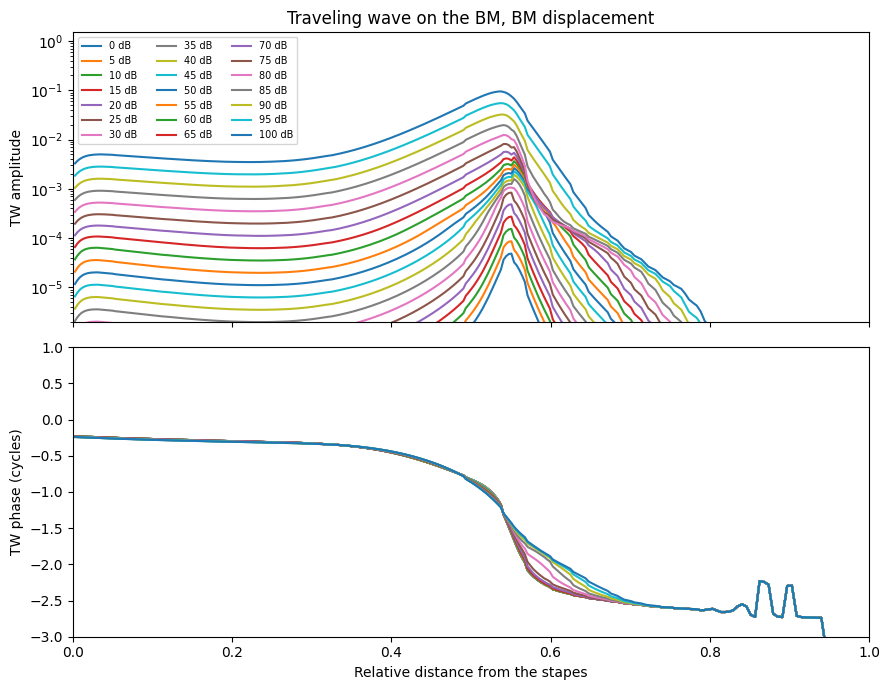

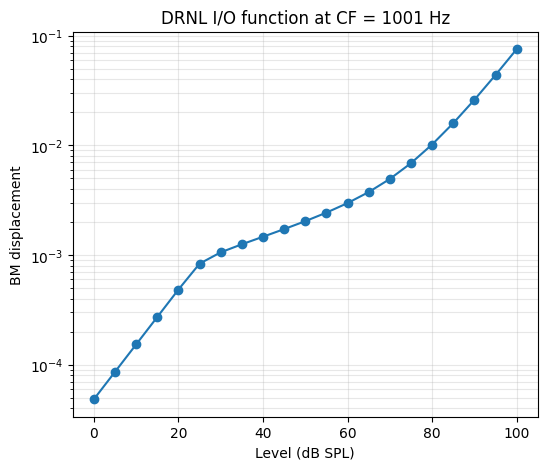

In [5]:
fs = 40e3          # sampling rate, Hz
freq = 1e3          # probe tone frequency, Hz
Lvect = np.arange(0, 101, 5)   # tone levels, dB SPL

CF = CF_full.copy()  # low -> high, as required by drnl()

scaleDRNL = 5e-4     # scales the input so nonlinearity kicks in ~30 dB SPL @ 1 kHz

Rdur = 10e-3         # onset ramp duration (s)
Tonset = 30e-3        # onset time, to ensure we're in steady state
Nper = 30             # number of periods to simulate
Nonset = round(Tonset * fs)
Nstat = int(fs * Nper * 1 / freq)
Tdur = (Nonset + Nstat) / fs
tx = np.arange(0, Tdur + 1 / fs, 1 / fs)

sigIn = np.sqrt(2) * np.sin(2 * np.pi * freq * tx)

# raised-cosine onset ramp
rx = np.arange(0, Rdur + 1 / fs, 1 / fs)
rx = np.pi * rx / Rdur
rampUp = (1 + np.cos(rx + np.pi)) / 2
wholeramp = np.concatenate([rampUp, np.ones(len(sigIn) - len(rx))])
sigIn = sigIn * wholeramp

fx = np.arange(Nstat) * fs / Nstat
idxFreq = int(np.argmin(np.abs(fx - freq)))

IO = np.zeros(len(Lvect), dtype=complex)
travelling_waves = []   # excitation pattern (complex) per level, for plotting

for k, Lin in enumerate(Lvect):
    sigInLin = sigIn * scaleDRNL * 10 ** (Lin / 20) * 2e-5

    sigOutBM = drnl(fs, sigInLin, CF)
    seg = sigOutBM[Nonset:Nonset + Nstat, :]
    SpectBM = np.fft.fft(seg, axis=0) / Nstat * np.exp(-1j * 2 * np.pi * freq * Nstat / fs)
    ExcPatBM = SpectBM[idxFreq, :]

    if k == 0:  # channel with the largest response at the lowest level
        idxExc = int(np.argmax(np.abs(ExcPatBM)))

    IO[k] = ExcPatBM[idxExc]
    travelling_waves.append(ExcPatBM)

# NOTE: drnl() returns channels re-ordered HIGH->LOW CF (like the original cf_new),
# so idxExc must be looked up in that (reversed) order, not in `CF` (low->high).
print(f"Best-excited channel CF: {CF[::-1][idxExc]:.1f} Hz (probe tone {freq:.0f} Hz)")

x_pos = gaussgrid(len(CF))

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 7))
for Lin, ExcPatBM in zip(Lvect, travelling_waves):
    axes[0].plot(x_pos, np.abs(ExcPatBM), label=f"{Lin:.0f} dB")
    axes[1].plot(x_pos, np.unwrap(np.angle(ExcPatBM)) / (2 * np.pi))

axes[0].set_yscale('log')
axes[0].set_ylim(2e-6, 1.5e0)
axes[0].set_xlim(0, 1)
axes[0].set_ylabel('TW amplitude')
axes[0].set_title('Traveling wave on the BM, BM displacement')
axes[0].legend(ncol=3, fontsize=7, loc='upper left')

axes[1].set_xlim(0, 1)
axes[1].set_ylim(-3, 1)
axes[1].set_xlabel('Relative distance from the stapes')
axes[1].set_ylabel('TW phase (cycles)')

plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))
plt.semilogy(Lvect, np.abs(IO), marker='o')
plt.ylabel('BM displacement')
plt.xlabel('Level (dB SPL)')
plt.title(f'DRNL I/O function at CF = {CF[::-1][idxExc]:.0f} Hz')
plt.grid(True, which='both', alpha=0.3)
plt.show()


---
## 2. Iso-intensity responses

Fixes the model CF at 1 kHz and sweeps the stimulus frequency around it at a few fixed levels, showing BM displacement/sensitivity and phase as a function of frequency (an "iso-intensity" curve).

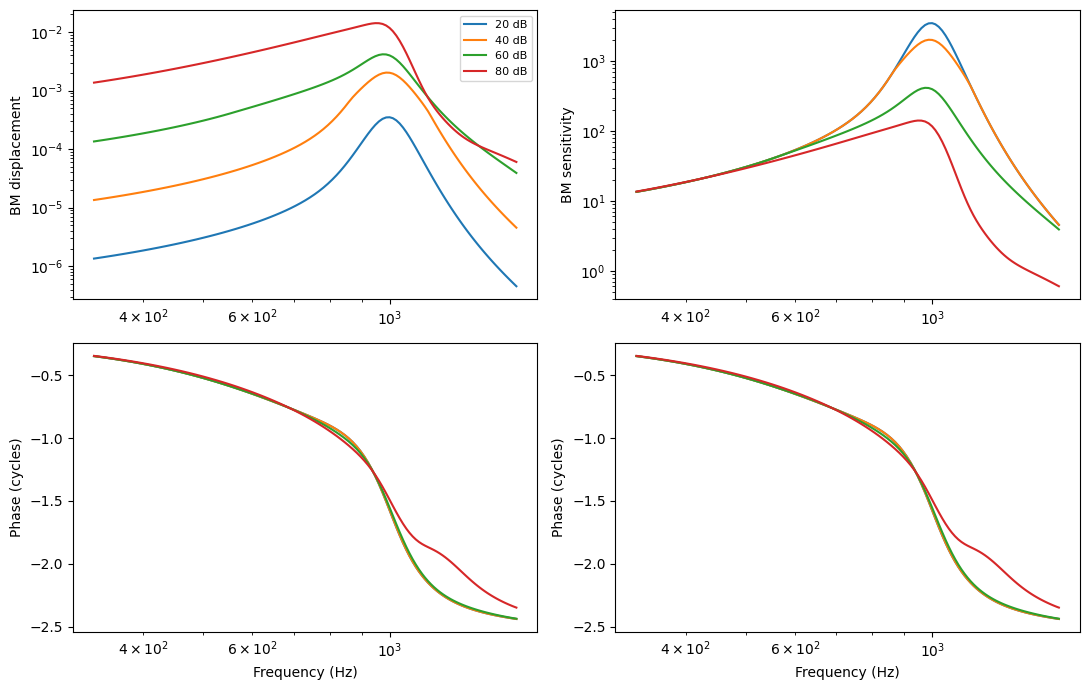

In [7]:
fs = 40e3
CF_single = 1e3     # single channel CF for this analysis
scaleDRNL = 5e-4

Rdur = 10e-3
Tonset = 30e-3
Nper = 30
Nonset = round(Tonset * fs)

freq_vect = np.round(np.linspace(CF_single / 3, 1.6 * CF_single, 100)).astype(int)
Lin_vect = [20, 40, 60, 80]  # dB SPL

NsampOpt = np.zeros(len(freq_vect), dtype=int)
for fv, f0 in enumerate(freq_vect):
    Nsampmin1 = []
    for k in range(1, 10001):
        Nsampmin = k * fs / f0
        if Nsampmin == round(Nsampmin):
            Nsampmin1.append(Nsampmin)
    NsampOpt[fv] = int(min(Nsampmin1))

iso_int = np.zeros((len(freq_vect), len(Lin_vect)), dtype=complex)

for m, Lin in enumerate(Lin_vect):
    for k, f0 in enumerate(freq_vect):
        Nstat = NsampOpt[k]
        Tdur = (Nonset + Nstat) / fs
        tx = np.arange(0, Tdur + 1 / fs, 1 / fs)
        sigInLin = np.sqrt(2) * np.sin(2 * np.pi * f0 * tx) * scaleDRNL * 10 ** (Lin / 20) * 2e-5

        rx = np.arange(0, Rdur + 1 / fs, 1 / fs)
        rx = np.pi * rx / Rdur
        rampUp = (1 + np.cos(rx + np.pi)) / 2
        wholeramp = np.concatenate([rampUp, np.ones(len(sigInLin) - len(rx))])
        sigInLin = sigInLin * wholeramp

        fx = np.arange(Nstat) * fs / Nstat
        idxFreq = int(np.argmin(np.abs(fx - f0)))

        sigOutBM = drnl(fs, sigInLin, np.array([CF_single]))
        seg = sigOutBM[Nonset:Nonset + Nstat, 0]
        SpectBM = np.fft.fft(seg) / Nstat * np.exp(-1j * 2 * np.pi * f0 * Nonset / fs)
        iso_int[k, m] = SpectBM[idxFreq]


level_scale = scaleDRNL * 10 ** (np.array(Lin_vect) / 20) * 2e-5

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].loglog(freq_vect, np.abs(iso_int))
axes[0, 0].set_ylabel('BM displacement')
axes[0, 0].legend([f"{L} dB" for L in Lin_vect], fontsize=8)

axes[1, 0].semilogx(freq_vect, np.unwrap(np.angle(iso_int), axis=0) / (2 * np.pi))
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].set_ylabel('Phase (cycles)')

sensitivity = iso_int / level_scale[np.newaxis, :]
axes[0, 1].loglog(freq_vect, np.abs(sensitivity))
axes[0, 1].set_ylabel('BM sensitivity')

axes[1, 1].semilogx(freq_vect, np.unwrap(np.angle(sensitivity), axis=0) / (2 * np.pi))
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('Phase (cycles)')

plt.tight_layout()
plt.show()

---
## 3. Two-tone suppression

A fixed 1 kHz probe tone (30 dB SPL) plus a 1200 Hz suppressor tone whose
level is varied. Shows how the BM response to the probe is suppressed as the
suppressor level increases, both as a traveling wave and as a spectrum at the
probe's CF place.

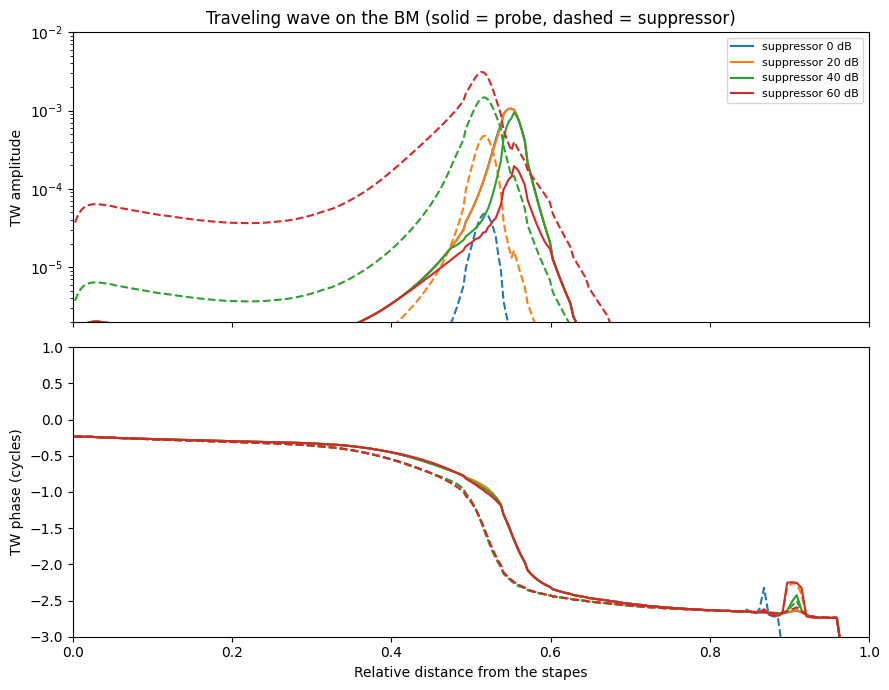

In [11]:
fs = 40e3
fp = 1e3       # probe frequency, Hz
Lp = 30        # probe level, dB SPL
fsup = 1200    # suppressor frequency, Hz

CF = CF_full.copy()  # full 300-channel CF map, low -> high
scaleDRNL = 5e-4

Rdur = 30e-3
Tonset = 30e-3
Nper = 30
Nonset = round(Tonset * fs)

ExcPatP_all, ExcPatSup_all = [], []
SpectBM_last = None  # spectrum at the last (highest) suppressor level, for §3.5

for Ls in Lsup_vect:
    sigSupin = sigSup * scaleDRNL * 10 ** (Ls / 20) * 2e-5

    sigOutBM = drnl(fs, sigPin + sigSupin, CF)
    seg = sigOutBM[Nonset:Nonset + Nstat, :]
    SpectBM = np.fft.fft(seg, axis=0) / Nstat
    SpectBM_last = SpectBM

    ExcPatP = SpectBM[idxFp, :] * np.exp(-1j * 2 * np.pi * fp * Nstat / fs)
    ExcPatSup = SpectBM[idxFsup, :] * np.exp(-1j * 2 * np.pi * fsup * Nstat / fs)
    ExcPatP_all.append(ExcPatP)
    ExcPatSup_all.append(ExcPatSup)

x_pos = gaussgrid(len(CF))

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 7))
for Ls, ExcPatP, ExcPatSup in zip(Lsup_vect, ExcPatP_all, ExcPatSup_all):
    line, = axes[0].plot(x_pos, np.abs(ExcPatP), label=f"suppressor {Ls} dB")
    axes[0].plot(x_pos, np.abs(ExcPatSup), color=line.get_color(), linestyle='--')

    axes[1].plot(x_pos, np.unwrap(np.angle(ExcPatP)) / (2 * np.pi), color=line.get_color())
    axes[1].plot(x_pos, np.unwrap(np.angle(ExcPatSup)) / (2 * np.pi), color=line.get_color(), linestyle='--')

axes[0].set_yscale('log')
axes[0].set_ylim(2e-6, 1e-2)
axes[0].set_xlim(0, 1)
axes[0].set_ylabel('TW amplitude')
axes[0].set_title('Traveling wave on the BM (solid = probe, dashed = suppressor)')
axes[0].legend(fontsize=8)

axes[1].set_xlim(0, 1)
axes[1].set_ylim(-3, 1)
axes[1].set_xlabel('Relative distance from the stapes')
axes[1].set_ylabel('TW phase (cycles)')

plt.tight_layout()
plt.show()

### 3.4 Plot: traveling wave for the probe (solid) and suppressor (dashed) at each suppressor level

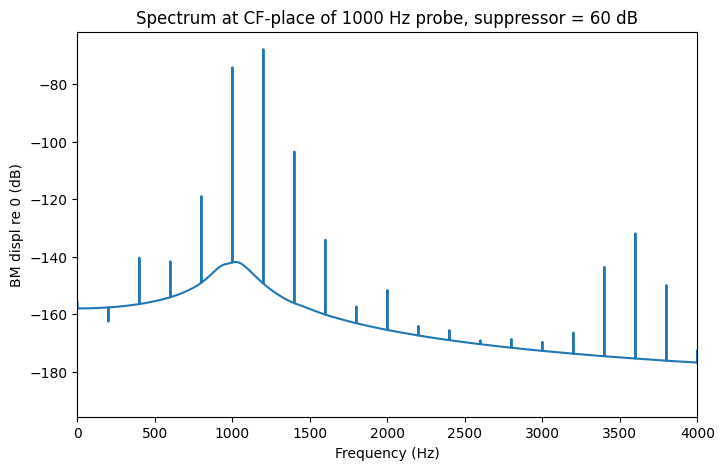

In [12]:
segFp = int(np.argmax(CF[::-1] <= fp))  # first channel (base->apex order) with CF <= fp

plt.figure(figsize=(8, 5))
plt.plot(fx, 20 * np.log10(np.abs(SpectBM_last[:, segFp])))
plt.xlim(0, 4e3)
plt.ylabel('BM displ re 0 (dB)')
plt.xlabel('Frequency (Hz)')
plt.title(f'Spectrum at CF-place of {fp:.0f} Hz probe, suppressor = {Lsup_vect[-1]} dB')
plt.show()